In [4]:
!pip install -q ultralytics

import os
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch

# фиксируем сид
SEED = 993

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("CUDA:", torch.cuda.is_available())

CUDA: True


In [7]:
from google.colab import files
uploaded = files.upload()

Saving train.zip to train.zip
Saving test.zip to test.zip


In [8]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv


In [10]:
DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(exist_ok=True)

# train
with zipfile.ZipFile("/content/train.zip", "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

# test
with zipfile.ZipFile("/content/test.zip", "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("После распаковки:")
print(os.listdir(DATA_DIR))

После распаковки:
['test', 'train']


In [12]:
for root, dirs, files in os.walk(DATA_DIR):
    print(root)
    print("dirs:", dirs[:3])
    print("files:", files[:3])
    print()

/content/data
dirs: ['test', 'train']
files: []

/content/data/test
dirs: ['images']
files: []

/content/data/test/images
dirs: []
files: ['IMG_20240228_132610_jpg.rf.adca94bedb75a482f55a08ebe1886e7c.jpg', 'IMG_20240228_124721_jpg.rf.e6866b635f043c95380d45c783aa281c.jpg', 'IMG_20240309_115958_jpg.rf.78225ec9fab634e4b1d0998819814f23.jpg']

/content/data/train
dirs: ['labels', 'images']
files: []

/content/data/train/labels
dirs: []
files: ['IMG20240306143852_jpg.rf.f5a03aa1073fdf0fc09209095f3c6968.txt', 'IMG_20240220_134820_jpg.rf.accf8c22fbc0c4bacac341c3d9c1fd24.txt', 'IMG20240309112733_jpg.rf.d57bde23b0a648916e074465cae32fe5.txt']

/content/data/train/images
dirs: []
files: ['IMG_20240228_141214_jpg.rf.5c2205dd2eae947913ca0bbc92040a76.jpg', 'IMG_20240228_135634_jpg.rf.805f8711e9e906d6d8bfb14f525429f9.jpg', 'IMG_20240417_115717_jpg.rf.91fe125a2bf99bf321b5a74ef153d01b.jpg']



## **EDA**



In [13]:
from pathlib import Path
from collections import Counter

TRAIN_IMG_DIR = Path("/content/data/train/images")
TRAIN_LABEL_DIR = Path("/content/data/train/labels")
TEST_IMG_DIR = Path("/content/data/test/images")

train_images = sorted(list(TRAIN_IMG_DIR.glob("*")))
train_labels = sorted(list(TRAIN_LABEL_DIR.glob("*.txt")))
test_images = sorted(list(TEST_IMG_DIR.glob("*")))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Test images:", len(test_images))

print("Example train image:", train_images[0].name)
print("Example train label:", train_labels[0].name)
print("Example test image:", test_images[0].name)

Train images: 1697
Train labels: 1697
Test images: 424
Example train image: IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9c4ababc261f.jpg
Example train label: IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9c4ababc261f.txt
Example test image: IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c.jpg


In [14]:
class_counts = Counter()
boxes_per_image = []

for label_path in train_labels:
    with open(label_path, "r") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    boxes_per_image.append(len(lines))

    for line in lines:
        parts = line.split()
        cls = int(parts[0])
        class_counts[cls] += 1

print("Всего объектов:", sum(class_counts.values()))
print("Классов найдено:", len(class_counts))
print("Минимальный класс:", min(class_counts.keys()))
print("Максимальный класс:", max(class_counts.keys()))

missing_classes = [i for i in range(52) if i not in class_counts]
print("Классы без объектов:", missing_classes)

Всего объектов: 10498
Классов найдено: 52
Минимальный класс: 0
Максимальный класс: 51
Классы без объектов: []


In [15]:
class_df = pd.DataFrame({
    "class_id": list(range(52)),
    "objects_count": [class_counts.get(i, 0) for i in range(52)]
})

class_df.sort_values("objects_count", ascending=False).head(10)

,class_id,objects_count
50,50,853
51,51,452
26,26,327
32,32,290
34,34,289
40,40,277
29,29,276
39,39,274
10,10,263
13,13,256


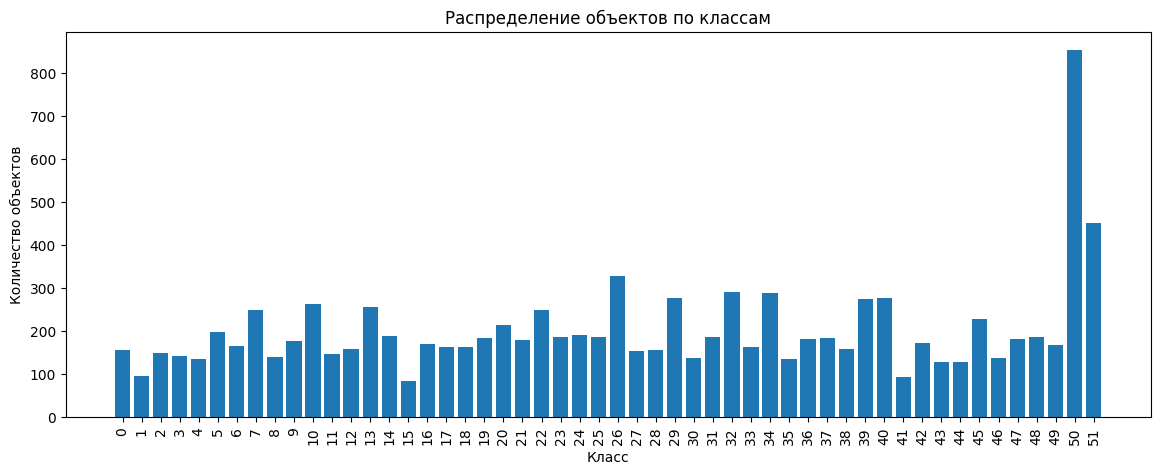

In [16]:
plt.figure(figsize=(14, 5))
plt.bar(class_df["class_id"], class_df["objects_count"])
plt.title("Распределение объектов по классам")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.xticks(class_df["class_id"], rotation=90)
plt.show()

       boxes_count
count  1697.000000
mean      6.186211
std       2.660769
min       1.000000
25%       5.000000
50%       6.000000
75%       8.000000
max      16.000000


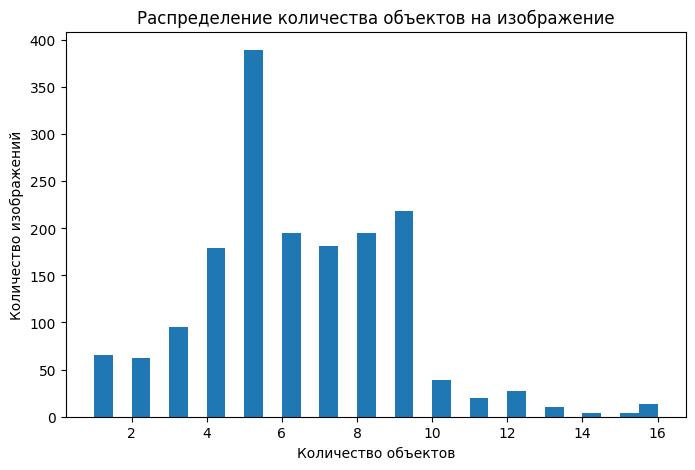

Картинок без объектов: 0
Максимум объектов на одной картинке: 16


In [17]:
boxes_df = pd.DataFrame({"boxes_count": boxes_per_image})

print(boxes_df.describe())

plt.figure(figsize=(8, 5))
plt.hist(boxes_per_image, bins=30)
plt.title("Распределение количества объектов на изображение")
plt.xlabel("Количество объектов")
plt.ylabel("Количество изображений")
plt.show()

print("Картинок без объектов:", sum(x == 0 for x in boxes_per_image))
print("Максимум объектов на одной картинке:", max(boxes_per_image))

        width  height
count  1697.0  1697.0
mean    640.0   640.0
std       0.0     0.0
min     640.0   640.0
25%     640.0   640.0
50%     640.0   640.0
75%     640.0   640.0
max     640.0   640.0


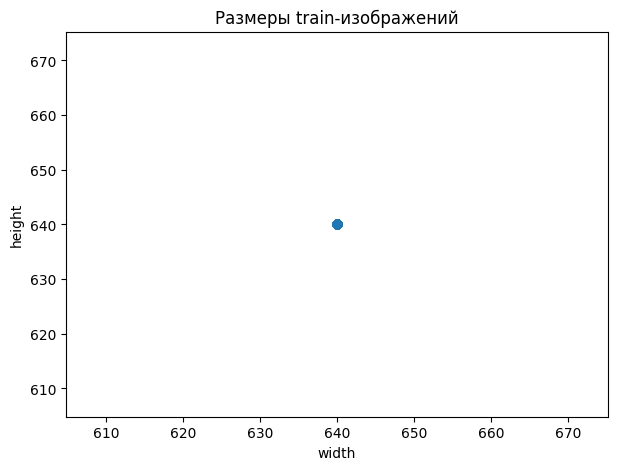

In [18]:
sizes = []

for img_path in train_images:
    img = Image.open(img_path)
    sizes.append(img.size)  # width, height

sizes_df = pd.DataFrame(sizes, columns=["width", "height"])

print(sizes_df.describe())

plt.figure(figsize=(7, 5))
plt.scatter(sizes_df["width"], sizes_df["height"], alpha=0.5)
plt.title("Размеры train-изображений")
plt.xlabel("width")
plt.ylabel("height")
plt.show()

In [19]:
import random
import matplotlib.patches as patches

def show_image_with_boxes(img_path):
    label_path = TRAIN_LABEL_DIR / (img_path.stem + ".txt")

    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(img)

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        for line in lines:
            cls, x_center, y_center, bw, bh = map(float, line.split())

            x1 = (x_center - bw / 2) * w
            y1 = (y_center - bh / 2) * h
            box_w = bw * w
            box_h = bh * h

            rect = patches.Rectangle(
                (x1, y1),
                box_w,
                box_h,
                linewidth=2,
                edgecolor="r",
                facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(
                x1, y1, str(int(cls)),
                color="white",
                fontsize=10,
                bbox=dict(facecolor="red", alpha=0.7)
            )

    ax.axis("off")
    plt.show()

random.seed(993)

for img_path in random.sample(train_images, 5):
    show_image_with_boxes(img_path)

Output hidden; open in https://colab.research.google.com to view.

### Обучение модели

In [20]:
import shutil
from sklearn.model_selection import train_test_split

YOLO_DIR = Path("/content/yolo_dataset")

for split in ["train", "val"]:
    (YOLO_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

train_img_paths = sorted(list(TRAIN_IMG_DIR.glob("*")))

train_part, val_part = train_test_split(
    train_img_paths,
    test_size=0.2,
    random_state=993,
    shuffle=True
)

def copy_image_and_label(img_paths, split):
    for img_path in img_paths:
        label_path = TRAIN_LABEL_DIR / f"{img_path.stem}.txt"

        shutil.copy(img_path, YOLO_DIR / split / "images" / img_path.name)

        if label_path.exists():
            shutil.copy(label_path, YOLO_DIR / split / "labels" / label_path.name)

copy_image_and_label(train_part, "train")
copy_image_and_label(val_part, "val")

print("Train split:", len(list((YOLO_DIR / "train/images").glob("*"))))
print("Val split:", len(list((YOLO_DIR / "val/images").glob("*"))))

Train split: 1357
Val split: 340


In [21]:
data_yaml = """
path: /content/yolo_dataset
train: train/images
val: val/images

nc: 52

names: [
""" + ", ".join([f"'class_{i}'" for i in range(52)]) + """
]
"""

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

print(data_yaml)


path: /content/yolo_dataset
train: train/images
val: val/images

nc: 52

names: [
'class_0', 'class_1', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_28', 'class_29', 'class_30', 'class_31', 'class_32', 'class_33', 'class_34', 'class_35', 'class_36', 'class_37', 'class_38', 'class_39', 'class_40', 'class_41', 'class_42', 'class_43', 'class_44', 'class_45', 'class_46', 'class_47', 'class_48', 'class_49', 'class_50', 'class_51'
]



In [18]:
from ultralytics import YOLO

model = YOLO("yolo11m.pt")

results = model.train(
    data="/content/data.yaml",
    epochs=30,
    imgsz=640,
    batch=4,
    seed=993,
    workers=2,
    project="/content/runs",
    name="yolo11m_detection_52_classes"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, in

In [20]:
from ultralytics import YOLO

best_model = YOLO(BEST_MODEL_PATH)


In [19]:
BEST_MODEL_PATH = "/content/runs/yolo11m_detection_52_classes/weights/best.pt"

import os
print(os.path.exists(BEST_MODEL_PATH))

True


In [64]:
from pathlib import Path

TEST_IMG_DIR = Path("/content/data/test/images")

predictions = best_model.predict(
    source=str(TEST_IMG_DIR),
    imgsz=640,
    conf=0.01,   # порог уверенности
    iou=0.5,     # под метрику AP@0.5
    max_det=300,
    save=False,
    augment=True
)


image 1/424 /content/data/test/images/IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1ac5492b4c81c.jpg: 640x640 1 class_0, 1 class_4, 1 class_5, 1 class_10, 7 class_12s, 10 class_16s, 1 class_20, 6 class_26s, 4 class_28s, 1 class_30, 4 class_33s, 3 class_34s, 2 class_37s, 1 class_40, 2 class_50s, 2 class_51s, 92.2ms
image 2/424 /content/data/test/images/IMG20240228122949_jpg.rf.f763b523e7bb4e72507961519cbbef88.jpg: 640x640 1 class_3, 1 class_30, 3 class_50s, 1 class_51, 92.4ms
image 3/424 /content/data/test/images/IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34c4074004853.jpg: 640x640 1 class_0, 1 class_4, 4 class_5s, 1 class_7, 1 class_11, 1 class_15, 1 class_26, 1 class_28, 3 class_43s, 2 class_44s, 1 class_45, 4 class_46s, 2 class_50s, 4 class_51s, 88.0ms
image 4/424 /content/data/test/images/IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52e60cd81b796.jpg: 640x640 1 class_0, 2 class_4s, 1 class_10, 5 class_11s, 6 class_12s, 1 class_24, 2 class_26s, 1 class_27, 2 class_28s, 2 class_29s, 2

In [70]:
sample_submission = pd.read_csv("/content/sample_submission.csv")

submission_rows = []

for result in predictions:
    image_id = Path(result.path).stem
    pred_parts = []

    boxes = result.boxes

    if boxes is not None and len(boxes) > 0:
        xyxy = boxes.xyxy.cpu().numpy()
        cls = boxes.cls.cpu().numpy().astype(int)
        conf = boxes.conf.cpu().numpy()

        for class_id, score, box in zip(cls, conf, xyxy):
            x1, y1, x2, y2 = box

            pred_parts.extend([
                str(class_id),
                str(round(float(score), 6)),
                str(round(float(x1), 2)),
                str(round(float(y1), 2)),
                str(round(float(x2), 2)),
                str(round(float(y2), 2))
            ])

    submission_rows.append({
        "image_id": image_id,
        "PredictionString": " ".join(pred_parts)
    })

submission_pred = pd.DataFrame(submission_rows)

submission = sample_submission[["image_id"]].merge(
    submission_pred,
    on="image_id",
    how="left"
)

# 🔥 фиксим null и пустые строки
DUMMY_PRED = "0 0.000001 0 0 1 1"

submission["PredictionString"] = submission["PredictionString"].fillna(DUMMY_PRED)
submission["PredictionString"] = submission["PredictionString"].astype(str)
submission.loc[submission["PredictionString"].str.strip() == "", "PredictionString"] = DUMMY_PRED

In [71]:
print("NaN:", submission["PredictionString"].isna().sum())
print("Пустых:", (submission["PredictionString"].str.strip() == "").sum())

NaN: 0
Пустых: 0


In [72]:
submission.to_csv("/content/submission_conf001.csv", index=False)

submission.head()

,image_id,PredictionString
0,IMG20240228122809_jpg.rf.bb184f37aa98d96f1db1a...,12 0.839094 171.66 537.7 277.52 611.51 16 0.74...
1,IMG20240228122949_jpg.rf.f763b523e7bb4e7250796...,51 0.465249 48.57 118.44 366.95 350.5 3 0.1661...
2,IMG20240228122955_jpg.rf.18d6c6ad9c8c69153da34...,51 0.649681 130.18 231.87 423.15 584.34 43 0.5...
3,IMG20240228123115_jpg.rf.3b9ae83d0bc7242bafe52...,28 0.766611 177.03 428.4 297.96 531.27 4 0.719...
4,IMG20240228123131_jpg.rf.84cf43cf1c7a8d09dc507...,0 0.678507 459.97 0.61 546.76 164.56 43 0.4624...


In [73]:
from google.colab import files
files.download("/content/submission_conf001.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>